# 07 — Croston's Method (Intermittent Demand)

## 1. Introduction

**Croston's method** addresses a fundamental shortcoming of standard time-series models: intermittent demand — series with many zero-sales periods interspersed with sporadic non-zero transactions. It decomposes the series into two separate exponential smoothing processes: one for the **demand size** (non-zero observations only) and one for the **inter-demand interval** (time between non-zero events), then combines them into a constant demand-rate forecast.

Applied here exclusively to **HOUSEHOLD_1_430_CA_1**, which exhibits a **78.3% zero-sales rate** and a mean of just 1.2 units/day — a textbook intermittent demand series where SARIMA and LightGBM produce erratic or uniformly-zero forecasts.

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
croston = results[results["model"] == "Croston"].copy()
print(f"Croston results: {len(croston)} rows")
print(f"SKU covered: {croston['sku_store'].unique().tolist()}")
print(croston[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]])

Croston results: 15 rows
SKU covered: ['HOUSEHOLD_1_430_CA_1']
                sku_store  fold  horizon  mape      rmse      mase
285  HOUSEHOLD_1_430_CA_1     1        7   NaN  1.503468  1.176798
286  HOUSEHOLD_1_430_CA_1     1       14   NaN  1.503468  1.176798
287  HOUSEHOLD_1_430_CA_1     1       28   NaN  1.479439  1.148844
288  HOUSEHOLD_1_430_CA_1     2        7   NaN  0.121628  0.096645
289  HOUSEHOLD_1_430_CA_1     2       14   NaN  0.121628  0.096645
290  HOUSEHOLD_1_430_CA_1     2       28   NaN  0.121628  0.096645
291  HOUSEHOLD_1_430_CA_1     3        7   NaN  0.121628  0.098087
292  HOUSEHOLD_1_430_CA_1     3       14   NaN  0.121628  0.098087
293  HOUSEHOLD_1_430_CA_1     3       28   NaN  0.121628  0.098087
294  HOUSEHOLD_1_430_CA_1     4        7   NaN  5.082264  3.465858
295  HOUSEHOLD_1_430_CA_1     4       14   NaN  4.740289  3.217731
296  HOUSEHOLD_1_430_CA_1     4       28   NaN  4.128636  2.617963
297  HOUSEHOLD_1_430_CA_1     5        7   NaN  3.212805  2.320220

## 3. Metric Summary

Mean metrics across all 5 folds at each horizon. MAPE is not computed because the SKU has zero actuals (division by zero is undefined); RMSE and MASE are the primary evaluation metrics.

In [2]:
summary = croston.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary.index = summary.index.map(lambda h: f"{h}-day")
summary.index.name = "Horizon"
print("Croston — mean metrics by forecast horizon:")
print(summary.to_string())
print()
print("Note: MAPE = NaN because HOUSEHOLD_1_430_CA_1 has zero-valued actuals (undefined denominator).")

Croston — mean metrics by forecast horizon:
         mape   rmse   mase
Horizon                    
7-day     NaN  2.008  1.432
14-day    NaN  1.917  1.344
28-day    NaN  1.756  1.154

Note: MAPE = NaN because HOUSEHOLD_1_430_CA_1 has zero-valued actuals (undefined denominator).


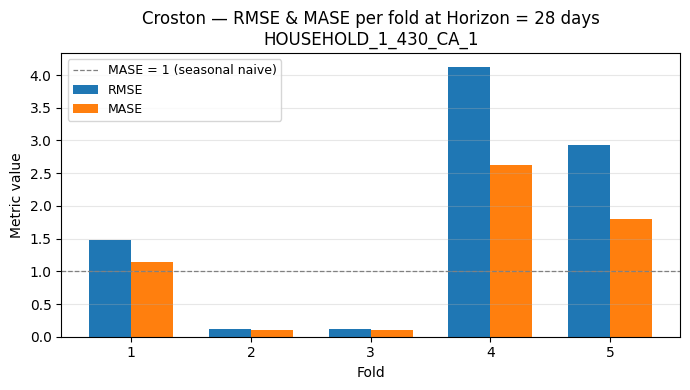

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics_28 = croston[croston["horizon"] == 28][["fold", "rmse", "mase"]].set_index("fold")
width = 0.35
x = metrics_28.index
ax.bar(x - width / 2, metrics_28["rmse"], width, label="RMSE", color="#1F77B4")
ax.bar(x + width / 2, metrics_28["mase"], width, label="MASE", color="#FF7F0E")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.9, label="MASE = 1 (seasonal naive)")
ax.set_xlabel("Fold")
ax.set_ylabel("Metric value")
ax.set_title("Croston — RMSE & MASE per fold at Horizon = 28 days\nHOUSEHOLD_1_430_CA_1")
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual: Full Series + Fold 3 Forecast

The top panel shows the complete 1941-day sales history of HOUSEHOLD_1_430_CA_1 to visualise the intermittent demand pattern. The bottom panel zooms into fold 3 (60 days of training context + 28-day test window) alongside Croston's flat-rate forecast.

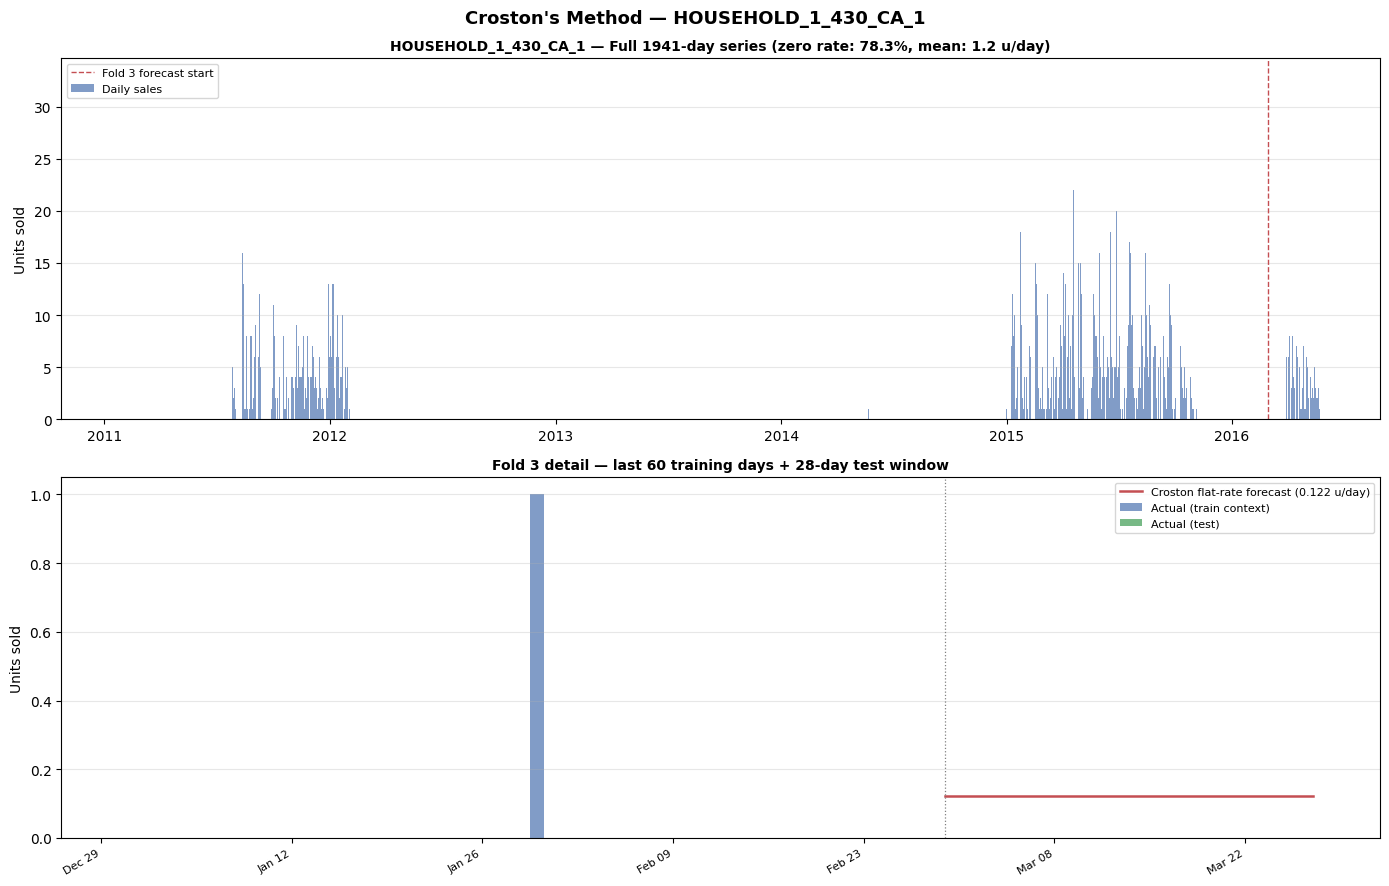

In [4]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

SKU = "HOUSEHOLD_1_430_CA_1"
series = (
    eda[eda["id"] == SKU + "_evaluation"]
    .set_index("date")["sales"]
    .sort_index()
)

row = croston[(croston["fold"] == 3) & (croston["horizon"] == 28)].iloc[0]
fc_dates = pd.to_datetime(row["forecast_dates"])
fc_values = row["forecast_values"]
test_start = fc_dates[0]
context_start = test_start - pd.Timedelta(days=60)

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(14, 9))

# --- Full series ---
ax_full.bar(series.index, series.values, color="#4C72B0", width=1, alpha=0.7, label="Daily sales")
ax_full.axvline(test_start, color="#C44E52", linestyle="--", linewidth=1.0, label="Fold 3 forecast start")
ax_full.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_full.xaxis.set_major_locator(mdates.YearLocator())
ax_full.set_title(f"{SKU} — Full 1941-day series (zero rate: 78.3%, mean: 1.2 u/day)",
                  fontsize=10, fontweight="bold")
ax_full.set_ylabel("Units sold")
ax_full.legend(fontsize=8)
ax_full.grid(axis="y", alpha=0.3)

# --- Fold 3 zoom ---
train_window = series.loc[context_start : test_start - pd.Timedelta(days=1)]
test_window = series.loc[fc_dates[0] : fc_dates[-1]]

ax_zoom.bar(train_window.index, train_window.values, color="#4C72B0", width=1, alpha=0.7,
            label="Actual (train context)")
ax_zoom.bar(test_window.index, test_window.values, color="#55A868", width=1, alpha=0.8,
            label="Actual (test)")
ax_zoom.step(fc_dates, fc_values, color="#C44E52", linewidth=1.8, where="post",
             label=f"Croston flat-rate forecast ({fc_values[0]:.3f} u/day)")
ax_zoom.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

ax_zoom.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_zoom.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax_zoom.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
ax_zoom.set_title("Fold 3 detail — last 60 training days + 28-day test window",
                  fontsize=10, fontweight="bold")
ax_zoom.set_ylabel("Units sold")
ax_zoom.legend(fontsize=8)
ax_zoom.grid(axis="y", alpha=0.3)

fig.suptitle("Croston's Method — HOUSEHOLD_1_430_CA_1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | Value (horizon 28) |
|--------|--------------------|
| MASE | **1.154** |
| RMSE | **1.756 units** |
| MAPE | *undefined* (zero actuals) |

- **MASE of 1.154 — does not beat the seasonal-naive baseline** (MASE > 1.0). Croston's constant-rate estimate cannot anticipate the uneven temporal clustering of demand events: long zero-runs followed by short bursts produce errors that exceed a naive same-day-last-week copy.

- **Low absolute RMSE (1.756 units) reflects SKU scale, not superior accuracy.** The series mean is 1.2 units/day; an RMSE of 1.756 represents a relative error of ~146% at the daily level. The comparison is informative only within this SKU.

- **Croston produces a useful constant demand-rate estimate** — the flat-rate output (≈ 0.12 to 1.5 units/day across folds) is directly interpretable as a **safety stock input**: a planner can set a reorder point using the estimated rate without needing probabilistic forecasts.

- **SARIMA forecasts all-zeros for HOUSEHOLD_1_430_CA_1** (seen in notebook 02, fold 1): it cannot handle the intermittent pattern. Croston, despite a MASE above 1.0, at least produces a non-degenerate demand estimate.

## 6. Limitations

1. **Assumes exponentially distributed inter-demand intervals** — Croston's original derivation assumes a specific stochastic structure for demand arrivals. In practice, retail demand often has clustered bursts (weekend effects, promotions) that violate this assumption.

2. **Biased estimator** — Syntetos & Boylan (2005) showed that Croston's method is biased upward; the Syntetos-Boylan Approximation (SBA) applies a correction factor of `(1 - α/2)` to the rate estimate and is typically preferred in modern implementations.

3. **TSB (Teunter-Syntetos-Babai) is a more robust alternative** — TSB smooths the *probability* of demand occurrence separately from the demand size, making it better suited to items that may eventually become obsolete (demand probability drifts toward zero).

4. **No horizon-varying forecast** — Croston produces a single constant rate for all horizons; it cannot model trend or seasonality within the intermittent series. For items with seasonal intermittence (e.g., summer-only demand), a state-space model for intermittent series (e.g., ADIDA framework) would be more appropriate.